# **1. Project Overview**

## 1.1 Business Objective

The objective of this project is building machine learning models that can accurately predict housing prices based on property characteristics.
Accurate housing price predictions can support real estate agencies, buyers, sellers, and property investors in making informed decisions.
The model help find key factors influencing house prices and improve pricing consistency in the housing market.

## 1.2 Hypothesis

The hypothesis was largely supported. Throughout the modelling experiments, property quality, living area, construction year, and basement size consistently emerged as important predictors of housing prices. In particular, `Overall Qual` and `Gr Liv Area` were identified as the most influential variables across multiple models. These findings confirm that housing prices are strongly influenced by factors related to property quality, size, and age.

# **2. Load Final Model**

In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import joblib

In [21]:
# Load Final Model - Grandient Boosting Regressor
final_model = joblib.load('../outputs/gradient_boosting_model.pkl')

# Load Datasets
X_train = pd.read_csv('../data/X_train_processed.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
X_test = pd.read_csv('../data/X_test_processed.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

# **3. Model Comparison**

## 3.1 Performance Summary Table

In [3]:
# Performance Comparison of all Evaluated Models on the Test Datset
comparison_df = pd.DataFrame({
    'Model': [
        'Dummy Regressor',
        'Linear Regression',
        'ElasticNet',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Test_RMSE': [
        0.4380,
        0.1506,
        0.1515,
        0.1555,
        0.1472
    ],
    'Test_MAE': [
        0.3459,
        0.1074,
        0.1080,
        0.1040,
        0.1002
    ],
    'Test_R2': [
        -0.0088,
        0.8808,
        0.8793,
        0.8729,
        0.8861
    ]
})

comparison_df

,Model,Test_RMSE,Test_MAE,Test_R2
0,Dummy Regressor,0.4380,0.3459,-0.0088
1,Linear Regression,0.1506,0.1074,0.8808
2,ElasticNet,0.1515,0.1080,0.8793
3,Random Forest,0.1555,0.1040,0.8729
4,Gradient Boosting,0.1472,0.1002,0.8861


## 3.2 Model Ranking

In [6]:
comparison_df.sort_values(by = 'Test_RMSE')

,Model,Test_RMSE,Test_MAE,Test_R2
4,Gradient Boosting,0.1472,0.1002,0.8861
1,Linear Regression,0.1506,0.1074,0.8808
2,ElasticNet,0.1515,0.1080,0.8793
3,Random Forest,0.1555,0.1040,0.8729
0,Dummy Regressor,0.4380,0.3459,-0.0088


### **Gradient Boosting** ###
This model achieved the strongest overall performance. It produced the lowest test RMSE and highest test R2 score. Linear Regression achieved competitive performance despite its simplicity, while Random Forest exhibited signs of overfitting and did not generalise as effectively to unseen data.

# **4. Final Model Evaluation**

## 4.1 Inverse Log Transformation

In [7]:
y_test_pred = final_model.predict(X_test)

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_test_pred)

## 4.2 Original Scale Performance

In [8]:
# Import RMSE, MAE from sklearn
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae

In [18]:
rmse(y_test_actual, y_pred_actual)
mae(y_test_actual, y_pred_actual)

33400.908878368085
18766.129616074828


To improve predictive performance, `SalePrice` was log-transformed during model training. Predictions were converted back to the original dollar scale using the inverse logarithmic transformation for business evaluation. The final Gradient Boosting model achieved an RMSE of approximately $33,401 and an MAE of approximately $18,766. This indicates that the model's predictions differ from actual housing prices by around $18,766 on average.

## 4.3 Actual vs Predicted

In [19]:
import matplotlib.pyplot as plt

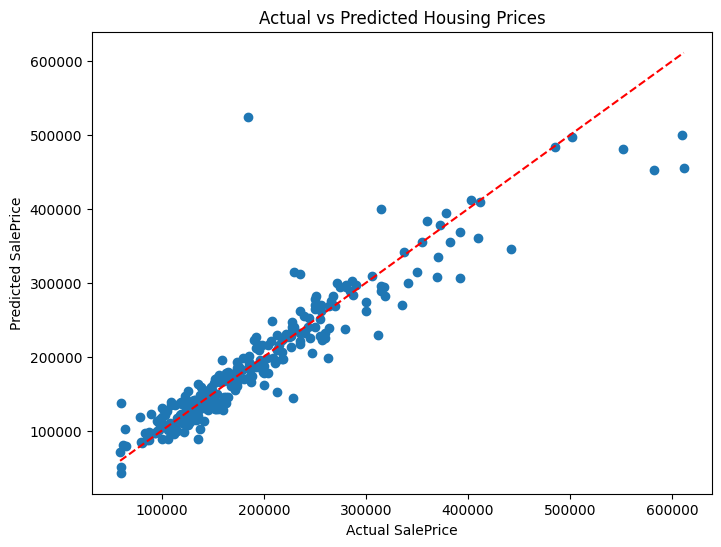

In [20]:
# Compare Actual and Predicted Housing Prices in the Original Scale
plt.figure(figsize = (8,6))

plt.scatter(
    y_test_actual,
    y_pred_actual
)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    'r--'
)

plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted Housing Prices')

plt.show()

The Actual vs Predicted plot demonstrates a strong agreement between observed and predicted housing prices in the original dollar scale. The final Gradient Boosting model is capable of producing accurate housing price estimates across a wide range of property values as most predictions are located close to the ideal prediction line.

# **5. Cross Validation Assessment**

In [22]:
# Perform 5-Fold Cross Validation for the Final Gradient Boosting Model

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

cv_model = GradientBoostingRegressor(
    n_estimators = 100,
    max_depth = 5,
    learning_rate= 0.1,
    random_state=42
)

cv_scores = cross_val_score(
    cv_model,
    X_train,
    y_train,
    cv = 5,
    scoring = 'neg_root_mean_squared_error'
)

cv_rmse_scores = -cv_scores

cv_rmse_scores

array([0.14230872, 0.15066285, 0.1580034 , 0.15760346, 0.13885704])

In [23]:
# Calculate Mean and Standard Deviation of Cross-Validation RMSE
print("CV RMSE Scores:", cv_rmse_scores)
print("Mean CV RMSE:", cv_rmse_scores.mean())
print('Standard Deviation:', cv_rmse_scores.std())

CV RMSE Scores: [0.14230872 0.15066285 0.1580034  0.15760346 0.13885704]
Mean CV RMSE: 0.149487094300066
Standard Deviation: 0.007801442333998446


5-fold cross-validation was conducted to further evalauate the robustness of the final Gradient Boosting model. The model achieved an average RMSE of 0.149 with a standard deviation of 0.008 across the five folds. The small standard deviation means that model performance remained stable across different training and validation splits. Furthermore, the mean cross-validation RMSE was highly consistent with the test RMSE obtained earlier. It suggests that the model generalises well to unseen data and is not overly dependant on a specific data split.

# **6. Final Conclusions**

- This project developed and evaluated multiple machine learning models for predicting housing prices using the Ames Housing dataset. Following exploratory data analysis, data preprocessing, feature engineering, and model experimentation, **Gradient Boosting** was identified as the best-performing model.

- The final model achieved a test RMSE of 0.147 and a test R2 score of 0.886 on the log-transformed target variable. After converting predictions back to the original dollar scale, the model achieved an RMSE of approximately $33,401 and an MAE of approximately $18,766. Cross-validation results further demonstrated that the model generalises well to unseen data with a mean RMSE of 0.149 and a low standard deviation of 0.008.

Overall, the results indicate that property quality, living area, kitchen quality, construction year, and basement size are key drivers of housing prices. The final Gradient Boosting model provides a reliable approach for estimating residential property values and demonstrates strong predictive performance across a range of housing characteristics.